# Bayesian Thinking for Real Decision Making

## Purpose and scope

These notes connect Bayesian reasoning with practical binary classification. The central theme is that a model output is not only a class label; it is often a probability that must be checked, calibrated, and converted into a decision threshold.

Main concepts covered:

- prior, likelihood, and posterior probability;
- Bayes theorem and base-rate effect;
- Gaussian Naive Bayes;
- logistic regression as a probabilistic classifier;
- probability calibration and reliability diagrams;
- Brier score;
- threshold selection and cost-sensitive decisions.

## Prerequisites

Assumed background: basic probability, train/test split, classification metrics, and scikit-learn workflows. The Bayesian idea is first shown manually, then connected to predictive models.

In [ ]:
# Optional installation cell. Uncomment if any package is missing in your environment.
# !pip install numpy pandas matplotlib seaborn scipy statsmodels scikit-learn ucimlrepo openml

## Problem statement

In many real decisions, the question is not only **Which class is predicted?** but also **How confident is the model?** and **What is the cost of being wrong?**

Medical-like classification is a strong example: false negatives and false positives may have different consequences. We will use the Breast Cancer Wisconsin dataset from scikit-learn and study both classification performance and probability quality.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.precision', 4)

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, brier_score_loss, ConfusionMatrixDisplay
)

## Dataset description and source

Dataset: **Breast Cancer Wisconsin Diagnostic dataset**, loaded directly using `sklearn.datasets.load_breast_cancer()`.

Each row describes features computed from a digitized image of a breast mass. The target indicates malignant or benign diagnosis. This dataset is commonly used for binary classification and probabilistic decision-making demonstrations.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y_raw = data.target.copy()

# In sklearn's dataset, target names are ['malignant', 'benign'] and target=0 means malignant, target=1 means benign.
# For decision-making, define positive class as malignant = 1.
y = (y_raw == 0).astype(int)

df = X.copy()
df['malignant'] = y

print('Shape:', df.shape)
print('Original target names:', data.target_names)
print('Positive class used in this notebook: malignant = 1')
display(df.head())

Shape: (569, 31)
Original target names: ['malignant' 'benign']
Positive class used in this notebook: malignant = 1


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.589,153.40,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,1
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.398,74.08,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,1
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.585,94.03,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,1
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.445,27.23,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,1
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.438,94.44,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,1


## Class distribution and prior probability

The prior probability is the probability of a class before using individual feature evidence. In classification datasets, class frequency is a simple empirical prior.

,count,probability
benign (0),357,0.6274
malignant (1),212,0.3726


Empirical prior probability of malignant class: 0.3726


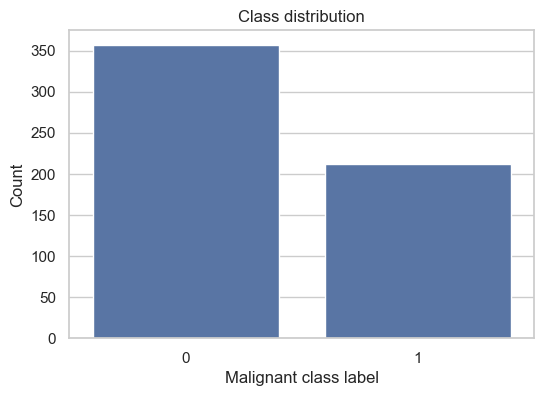

In [3]:
class_counts = df['malignant'].value_counts().sort_index()
class_probs = df['malignant'].value_counts(normalize=True).sort_index()
prior_table = pd.DataFrame({'count': class_counts, 'probability': class_probs})
prior_table.index = ['benign (0)', 'malignant (1)']
display(prior_table)

prior_malignant = df['malignant'].mean()
print(f'Empirical prior probability of malignant class: {prior_malignant:.4f}')

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='malignant')
plt.title('Class distribution')
plt.xlabel('Malignant class label')
plt.ylabel('Count')
plt.show()

## Compact concept note

Bayesian inference updates a prior belief after observing evidence. In classification, the class frequency can act as a simple empirical prior, while model features act as evidence. A high-quality classifier should therefore be evaluated in two ways: whether it separates classes correctly and whether its predicted probabilities are trustworthy.

## Manual Bayes theorem demonstration: base-rate effect

Suppose a disease has low prevalence. Even a test with high sensitivity and specificity may produce a posterior probability after a positive result that is lower than people expect.

Bayes theorem:

P(Disease | Positive) = P(Positive | Disease) P(Disease) / P(Positive)

where

P(Positive) = P(Positive | Disease)P(Disease) + P(Positive | No Disease)P(No Disease)

In [4]:
def posterior_after_positive(prevalence, sensitivity, specificity):
    p_disease = prevalence
    p_no_disease = 1 - prevalence
    p_pos_given_disease = sensitivity
    p_pos_given_no_disease = 1 - specificity
    p_positive = p_pos_given_disease * p_disease + p_pos_given_no_disease * p_no_disease
    posterior = (p_pos_given_disease * p_disease) / p_positive
    return posterior, p_positive

example = {
    'prevalence': 0.01,
    'sensitivity': 0.95,
    'specificity': 0.90
}
posterior, p_positive = posterior_after_positive(**example)
print(example)
print(f'P(Positive): {p_positive:.4f}')
print(f'P(Disease | Positive): {posterior:.4f}')

{'prevalence': 0.01, 'sensitivity': 0.95, 'specificity': 0.9}
P(Positive): 0.1085
P(Disease | Positive): 0.0876


### Interpretation guide

Even with high sensitivity and specificity, low prevalence can strongly limit the posterior probability after a positive test. This is the base-rate effect. Bayesian thinking forces us to combine prior probability with evidence.

## Train/test split

We split the dataset into training and test sets. Stratification preserves the class proportion in both sets. Standardization is used for logistic regression because it is sensitive to feature scale.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train malignant prior:', y_train.mean())
print('Test malignant prior:', y_test.mean())

Train shape: (426, 30)
Test shape: (143, 30)
Train malignant prior: 0.3732394366197183
Test malignant prior: 0.3706293706293706


## Models

We compare:

1. **Gaussian Naive Bayes**: uses Bayes theorem with a strong conditional-independence assumption.
2. **Logistic Regression**: discriminative linear probabilistic classifier.
3. **Random Forest**: non-linear ensemble model, included as an optional performance comparison.

Naive Bayes can work surprisingly well even when independence is imperfect, but its probabilities may be poorly calibrated.

In [6]:
models = {
    'Gaussian Naive Bayes': GaussianNB(),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'Trained: {name}')

Trained: Gaussian Naive Bayes
Trained: Logistic Regression
Trained: Random Forest


## Evaluation framework

Accuracy alone is not enough. We compute:

- precision: among predicted malignant cases, how many are truly malignant;
- recall/sensitivity: among truly malignant cases, how many are detected;
- F1-score: balance of precision and recall;
- ROC-AUC: ranking quality across thresholds;
- PR-AUC: useful when positive class is less frequent;
- confusion matrix: actual decision errors;
- Brier score: probability accuracy/calibration quality.

In [7]:
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        'model': name,
        'threshold': threshold,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, proba),
        'pr_auc': average_precision_score(y_test, proba),
        'brier_score': brier_score_loss(y_test, proba)
    }

results = pd.DataFrame([evaluate_model(name, model, X_test, y_test) for name, model in models.items()])
display(results.sort_values('roc_auc', ascending=False))

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
2,Random Forest,0.5,0.9720,1.00,0.9245,0.9608,0.9983,0.9973,0.0280
1,Logistic Regression,0.5,0.9650,0.98,0.9245,0.9515,0.9962,0.9943,0.0224
0,Gaussian Naive Bayes,0.5,0.9441,1.00,0.8491,0.9184,0.9952,0.9920,0.0538


### Interpretation guide

Higher ROC-AUC and PR-AUC indicate better ranking. Lower Brier score indicates better probability predictions. A model can have high accuracy but poorly calibrated probabilities.

## Confusion matrices

A confusion matrix shows false positives and false negatives explicitly. In medical-like decisions, these error types may have unequal costs.

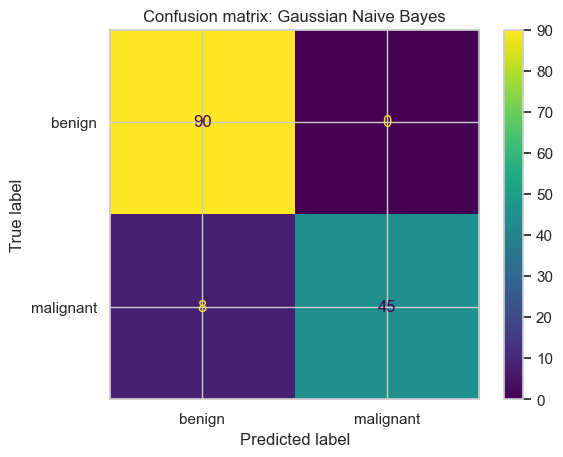

Gaussian Naive Bayes
              precision    recall  f1-score   support

      benign       0.92      1.00      0.96        90
   malignant       1.00      0.85      0.92        53

    accuracy                           0.94       143
   macro avg       0.96      0.92      0.94       143
weighted avg       0.95      0.94      0.94       143



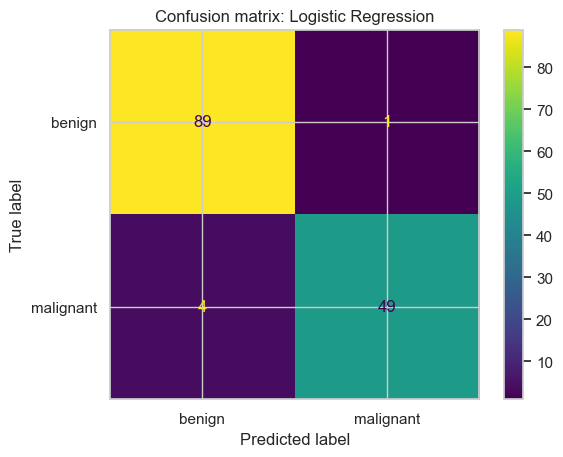

Logistic Regression
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        90
   malignant       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



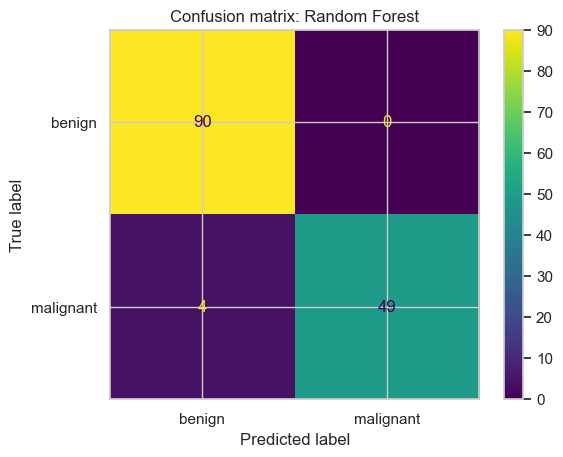

Random Forest
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        90
   malignant       1.00      0.92      0.96        53

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143



In [8]:
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['benign', 'malignant'])
    disp.plot(values_format='d')
    plt.title(f'Confusion matrix: {name}')
    plt.show()
    print(name)
    print(classification_report(y_test, pred, target_names=['benign', 'malignant']))

## Predicted probability histograms

A probabilistic classifier should not only separate classes; its probability values should be meaningful. Histograms show whether a model is overconfident, underconfident, or uncertain for many cases.

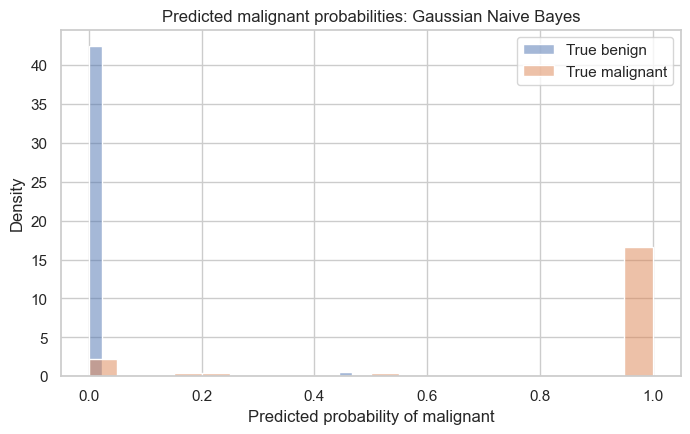

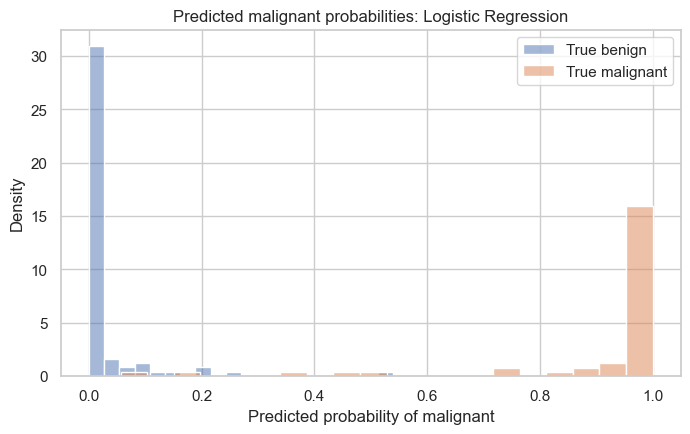

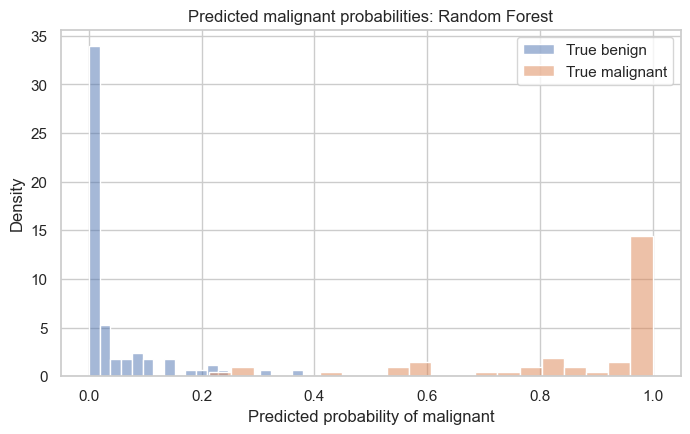

In [9]:
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    plt.figure(figsize=(8, 4.5))
    sns.histplot(proba[y_test == 0], bins=20, label='True benign', alpha=0.5, stat='density')
    sns.histplot(proba[y_test == 1], bins=20, label='True malignant', alpha=0.5, stat='density')
    plt.title(f'Predicted malignant probabilities: {name}')
    plt.xlabel('Predicted probability of malignant')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

## Calibration curves and Brier score

A reliability diagram compares predicted probability with observed frequency. For example, among cases assigned around 0.8 probability, roughly 80% should be positive if the model is well calibrated.

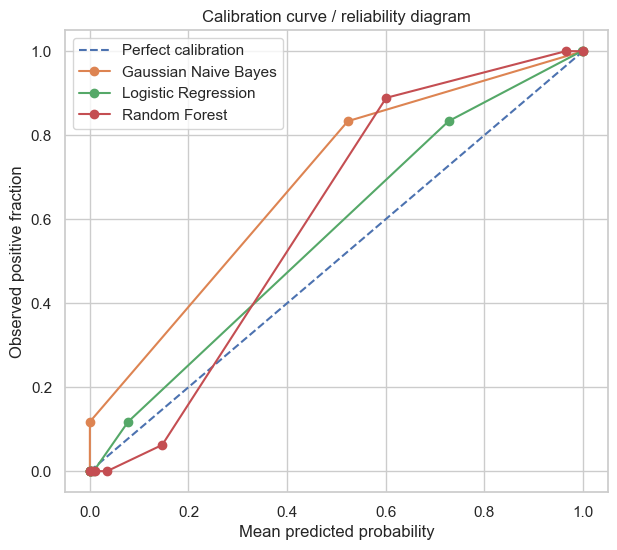

,model,brier_score
1,Logistic Regression,0.0224
2,Random Forest,0.0280
0,Gaussian Naive Bayes,0.0538


In [10]:
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=f'{name}')

plt.title('Calibration curve / reliability diagram')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed positive fraction')
plt.legend()
plt.show()

display(results[['model', 'brier_score']].sort_values('brier_score'))

### Interpretation guide

Curves close to the diagonal are better calibrated. Brier score summarizes squared probability error; lower is better. Calibration matters when probabilities guide decisions.

## Probability calibration

We calibrate Gaussian Naive Bayes using:

- sigmoid/Platt scaling;
- isotonic calibration.

Calibration must be learned using training data only. `CalibratedClassifierCV` handles this through internal cross-validation.

In [11]:
base_nb = GaussianNB()
calibrated_models = {
    'Naive Bayes uncalibrated': GaussianNB(),
    'Naive Bayes calibrated sigmoid': CalibratedClassifierCV(GaussianNB(), method='sigmoid', cv=5),
    'Naive Bayes calibrated isotonic': CalibratedClassifierCV(GaussianNB(), method='isotonic', cv=5),
}

for name, model in calibrated_models.items():
    model.fit(X_train, y_train)

cal_results = pd.DataFrame([evaluate_model(name, model, X_test, y_test) for name, model in calibrated_models.items()])
display(cal_results.sort_values('brier_score'))

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
2,Naive Bayes calibrated isotonic,0.5,0.9510,0.9792,0.8868,0.9307,0.9943,0.9896,0.0336
1,Naive Bayes calibrated sigmoid,0.5,0.9301,0.9778,0.8302,0.8980,0.9950,0.9916,0.0535
0,Naive Bayes uncalibrated,0.5,0.9441,1.0000,0.8491,0.9184,0.9952,0.9920,0.0538


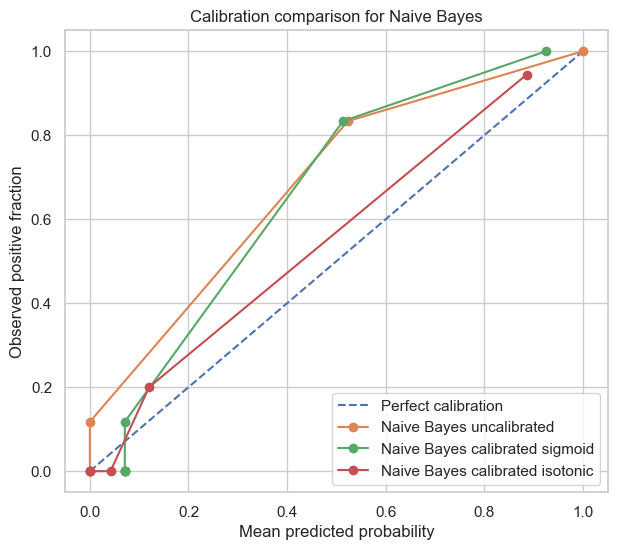

In [12]:
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')

for name, model in calibrated_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=name)

plt.title('Calibration comparison for Naive Bayes')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed positive fraction')
plt.legend()
plt.show()

## Threshold analysis

The default threshold 0.5 may not be optimal. If false negatives are more costly than false positives, we may lower the threshold to detect more malignant cases, accepting more false alarms.

,threshold,accuracy,precision,recall,false_positives,false_negatives,true_positives,true_negatives
0,0.05,0.9231,0.8281,1.0000,11,0,53,79
1,0.10,0.9510,0.8966,0.9811,6,1,52,84
2,0.15,0.9650,0.9286,0.9811,4,1,52,86
3,0.20,0.9650,0.9444,0.9623,3,2,51,87
4,0.25,0.9720,0.9623,0.9623,2,2,51,88
5,0.30,0.9790,0.9808,0.9623,1,2,51,89
6,0.35,0.9790,0.9808,0.9623,1,2,51,89
7,0.40,0.9720,0.9804,0.9434,1,3,50,89
8,0.45,0.9720,0.9804,0.9434,1,3,50,89
9,0.50,0.9650,0.9800,0.9245,1,4,49,89


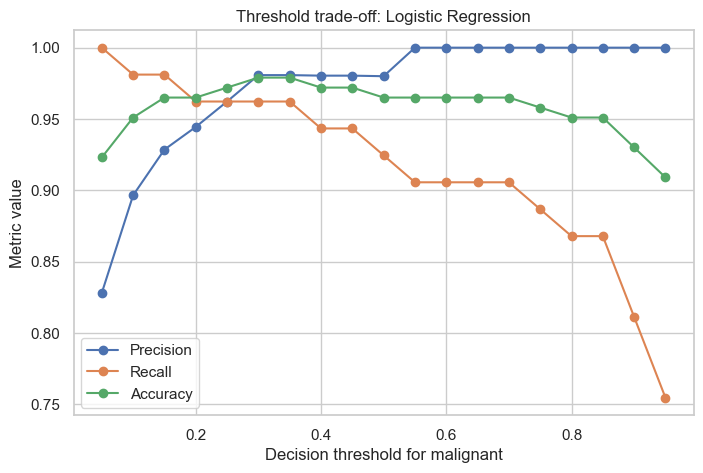

In [13]:
chosen_name = 'Logistic Regression'
chosen_model = models[chosen_name]
proba = chosen_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for thr in thresholds:
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({
        'threshold': thr,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp,
        'true_negatives': tn
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['accuracy'], marker='o', label='Accuracy')
plt.title(f'Threshold trade-off: {chosen_name}')
plt.xlabel('Decision threshold for malignant')
plt.ylabel('Metric value')
plt.legend()
plt.show()

### Interpretation guide

Lowering the threshold usually increases recall but can reduce precision. Raising the threshold usually reduces false positives but can increase false negatives. The best threshold depends on the real cost of each error.

## Cost-sensitive decision rule

Let us define a simple cost matrix:

- false negative cost = 10;
- false positive cost = 1;
- correct predictions cost = 0.

This is only an example. Real cost values must come from domain knowledge, medical guidelines, economic analysis, or stakeholder decisions.

,best_threshold_by_cost
threshold,0.0500
fp,11.0000
fn,0.0000
total_cost,11.0000
average_cost,0.0769


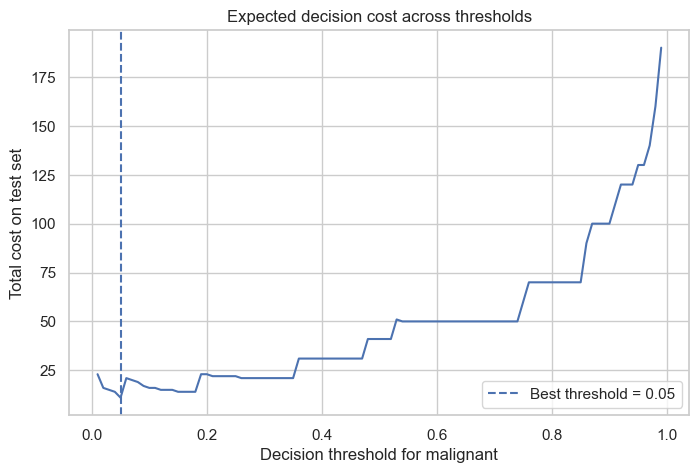

In [14]:
false_negative_cost = 10
false_positive_cost = 1

cost_rows = []
for thr in np.linspace(0.01, 0.99, 99):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    total_cost = false_positive_cost * fp + false_negative_cost * fn
    cost_rows.append({'threshold': thr, 'fp': fp, 'fn': fn, 'total_cost': total_cost, 'average_cost': total_cost / len(y_test)})

cost_df = pd.DataFrame(cost_rows)
best_row = cost_df.loc[cost_df['total_cost'].idxmin()]

display(best_row.to_frame('best_threshold_by_cost'))

plt.figure(figsize=(8, 5))
plt.plot(cost_df['threshold'], cost_df['total_cost'])
plt.axvline(best_row['threshold'], linestyle='--', label=f"Best threshold = {best_row['threshold']:.2f}")
plt.title('Expected decision cost across thresholds')
plt.xlabel('Decision threshold for malignant')
plt.ylabel('Total cost on test set')
plt.legend()
plt.show()

## Output-grounded analytical summary

The next cell summarizes model ranking, calibration, and threshold choice using the computed outputs. This keeps the final interpretation tied to the executed results rather than to assumed numbers.

In [15]:
best_auc_row = results.sort_values('roc_auc', ascending=False).iloc[0]
best_brier_row = results.sort_values('brier_score', ascending=True).iloc[0]

decision_summary = pd.Series({
    'empirical_prior_malignant': prior_malignant,
    'best_model_by_ROC_AUC': best_auc_row['model'],
    'best_ROC_AUC': best_auc_row['roc_auc'],
    'best_model_by_Brier_score': best_brier_row['model'],
    'best_Brier_score': best_brier_row['brier_score'],
    'cost_sensitive_best_threshold': best_row['threshold'],
    'minimum_total_cost_under_example_matrix': best_row['total_cost'],
    'decision_note': (
        'Classification performance, calibration, and decision cost can favor different choices; '
        'the final threshold should match the real decision context.'
    )
})
display(decision_summary.to_frame('diagnostic_summary'))

,diagnostic_summary
empirical_prior_malignant,0.3726
best_model_by_ROC_AUC,Random Forest
best_ROC_AUC,0.9983
best_model_by_Brier_score,Logistic Regression
best_Brier_score,0.0224
cost_sensitive_best_threshold,0.05
minimum_total_cost_under_example_matrix,11.0
decision_note,"Classification performance, calibration, and d..."


## Limitations

- The dataset is clean and structured; real clinical data can contain missingness, acquisition bias, and population shift.
- The cost matrix is illustrative and must not be treated as a clinical recommendation.
- Calibration curves are estimated from a limited test set, so they can be noisy.
- Naive Bayes assumes conditional independence, which is unlikely for correlated image-derived features.
- Prediction and calibration do not explain biological causality.

## What we learned

- Bayesian reasoning combines prior probability with evidence.
- Base rates can strongly change posterior probabilities even when a test is accurate.
- A classifier should be evaluated by discrimination, calibration, and decision cost.
- Naive Bayes is simple and useful, but its probabilities may need calibration.
- The default threshold of 0.5 is not automatically optimal when error costs differ.

## Possible extensions

- Use nested cross-validation for more stable model comparison.
- Compare calibration under stronger class imbalance.
- Add cost-sensitive training and compare it with post-hoc threshold tuning.
- Add permutation importance or SHAP for feature-level interpretation.
- Repeat the workflow on SMS spam or credit-risk data.